In [442]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

plt.style.use("seaborn-v0_8-paper")
sns.set_palette("pastel")
plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.family"] = "Courier New"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 40
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["figure.dpi"] = 300

In [423]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    filepaths = sorted(glob.glob(file_pattern))
    if not filepaths:
        raise ValueError(f"No files matched pattern: {file_pattern}")
    dataframes = []
    for trial_id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df["trial_id"] = trial_id
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

In [424]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = "ordinal",
    strategy: str = "quantile",
    subsample: int | None = None,
    random_state: int | None = None,
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state,
        quantile_method="averaged_inverted_cdf",
    )
    X_transformed = discretizer.fit_transform(X_train)
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index,
    )
    return X_transformed_df, discretizer

In [425]:
def one_hot_encode_features(
    discretized_df: pd.DataFrame, n_bins_list: list[int]
) -> np.ndarray:
    encoded_parts = []
    for col_name, n_bins in zip(discretized_df.columns, n_bins_list):
        col_vals = discretized_df[col_name].astype(int).values
        one_hot = np.zeros((len(col_vals), n_bins), dtype=np.float32)
        one_hot[np.arange(len(col_vals)), col_vals] = 1.0
        encoded_parts.append(one_hot)
    return np.concatenate(encoded_parts, axis=1)

In [426]:
def generate_pair_diffs(
    X_np: np.ndarray,
    Y_np: np.ndarray,
    n_pairs: int,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.RandomState(seed)
    n = len(X_np)

    idx_a = rng.randint(0, n, size=n_pairs)
    idx_b = rng.randint(0, n, size=n_pairs)

    same = idx_a == idx_b
    while same.any():
        idx_b[same] = rng.randint(0, n, size=same.sum())
        same = idx_a == idx_b

    y_a = Y_np[idx_a]
    y_b = Y_np[idx_b]

    mask = y_a != y_b
    idx_a = idx_a[mask]
    idx_b = idx_b[mask]
    y_a = y_a[mask]
    y_b = y_b[mask]

    X_diff = X_np[idx_a] - X_np[idx_b]
    labels = (y_a < y_b).astype(np.float32)

    return X_diff, labels

In [427]:
file_pattern = '../data/afterkernel/mongo.csv'
output_dir = Path('outputs/gen5')
output_dir.mkdir(parents=True, exist_ok=True)

In [428]:
df = read_csvs_to_dataframe(file_pattern)
print(f"Loaded {len(df)} rows from pattern: {file_pattern}")

Loaded 13483 rows from pattern: ../data/afterkernel/mongo.csv


In [429]:
Y = df.groupby(["trial_id", "dm", "dn", "in", "of"])["pd"].shift(-1)
labeled = Y.notna().sum()
unlabeled = Y.isna().sum()
print(f"  Labeled rows: {labeled}  |  Unlabeled: {unlabeled}  |  Coverage: {labeled / len(Y) * 100:.2f}%")

Y.fillna(1e15, inplace=True)
Y_np = Y.values

  Labeled rows: 2181  |  Unlabeled: 11302  |  Coverage: 16.18%


In [430]:
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42
)
print(f"  Train rows: {len(train_idx)}  |  Test rows: {len(test_idx)}")

  Train rows: 10786  |  Test rows: 2697


In [431]:
discretize_cols = ["pd", "sz", "fq", "sd", "p2", "id", "i2", "ie"]

train_features_df = df.iloc[train_idx][discretize_cols].reset_index(drop=True)
test_features_df = df.iloc[test_idx][discretize_cols].reset_index(drop=True)

train_discretized, discretizer = train_and_transform_discretizer(
    train_features_df, n_bins=10, strategy="quantile"
)
n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(len(discretize_cols))]
print(f"Bins per discretized feature: {n_bins_list}")

test_discretized_np = discretizer.transform(test_features_df)
test_discretized = pd.DataFrame(
    test_discretized_np,
    columns=discretize_cols,
)

Bins per discretized feature: [10, 1, 2, 3, 3, 10, 10, 10]


/Users/jef/research/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/jef/research/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/jef/research/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/jef/research/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the numbe

In [432]:
X_train_full = one_hot_encode_features(train_discretized, n_bins_list)
X_test_full = one_hot_encode_features(test_discretized, n_bins_list)
n_encoded_features = X_train_full.shape[1]

print(f"Feature matrix shape: train={X_train_full.shape}, test={X_test_full.shape}")
print(f"  One-hot features: {n_encoded_features} (from bins {n_bins_list})")

Y_train_raw = Y_np[train_idx]
Y_test_raw = Y_np[test_idx]

Feature matrix shape: train=(10786, 49), test=(2697, 49)
  One-hot features: 49 (from bins [10, 1, 2, 3, 3, 10, 10, 10])


In [433]:
N_TRAIN_PAIRS = len(Y_train_raw) * 10
N_TEST_PAIRS = len(Y_test_raw) * 10

X_diff_train, Y_train_pairs = generate_pair_diffs(
    X_train_full, Y_train_raw, N_TRAIN_PAIRS, seed=42
)
X_diff_test, Y_test_pairs = generate_pair_diffs(
    X_test_full, Y_test_raw, N_TEST_PAIRS, seed=123
)

print(f"  Training pairs: {len(Y_train_pairs)}")
print(f"  Test pairs:     {len(Y_test_pairs)}")
print(f"  Train label balance (frac A sooner): {Y_train_pairs.mean():.3f}")
print(f"  Test  label balance (frac A sooner): {Y_test_pairs.mean():.3f}")

  Training pairs: 31885
  Test pairs:     8203
  Train label balance (frac A sooner): 0.504
  Test  label balance (frac A sooner): 0.504


In [434]:
import keras
from keras import layers
from keras.callbacks import EarlyStopping

input_diff = layers.Input(shape=(n_encoded_features,), name="feature_diff")
output = layers.Dense(1, activation="sigmoid", use_bias=False, name="ranking_weight")(input_diff)

model = keras.Model(inputs=input_diff, outputs=output, name="LinearPairwiseRanker")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "LinearPairwiseRanker"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_diff (InputLayer)       │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ranking_weight (Dense)          │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [435]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_diff_train,
    Y_train_pairs,
    epochs=50,
    batch_size=32,
    validation_data=(X_diff_test, Y_test_pairs),
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 1s 492us/step - accuracy: 0.9276 - loss: 0.2338 - val_accuracy: 0.9527 - val_loss: 0.1333
Epoch 2/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.9592 - loss: 0.1048 - val_accuracy: 0.9581 - val_loss: 0.0935
Epoch 3/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - accuracy: 0.9624 - loss: 0.0814 - val_accuracy: 0.9620 - val_loss: 0.0785
Epoch 4/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.9636 - loss: 0.0709 - val_accuracy: 0.9646 - val_loss: 0.0704
Epoch 5/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.9653 - loss: 0.0648 - val_accuracy: 0.9678 - val_loss: 0.0656
Epoch 6/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.9678 - loss: 0.0608 - val_accuracy: 0.9685 - val_loss: 0.0618
Epoch 7/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.9691 - loss: 0.0580 - val_accuracy: 0.9694 - val_loss: 0.0594
Epoch 8/50
997/997 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.9694 - loss: 0.0560 - 

In [436]:
Y_pred_prob = model.predict(X_diff_test, verbose=0).ravel()
Y_pred = (Y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(Y_test_pairs.astype(int), Y_pred)

report = classification_report(
    Y_test_pairs.astype(int),
    Y_pred,
    target_names=["B reused sooner", "A reused sooner"],
)

print(f"Pairwise Test Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs")
print("\nClassification Report:")
print(report)

Pairwise Test Accuracy: 0.9721
Trained for 37 epochs

Classification Report:
                 precision    recall  f1-score   support

B reused sooner       0.97      0.97      0.97      4067
A reused sooner       0.97      0.97      0.97      4136

       accuracy                           0.97      8203
      macro avg       0.97      0.97      0.97      8203
   weighted avg       0.97      0.97      0.97      8203



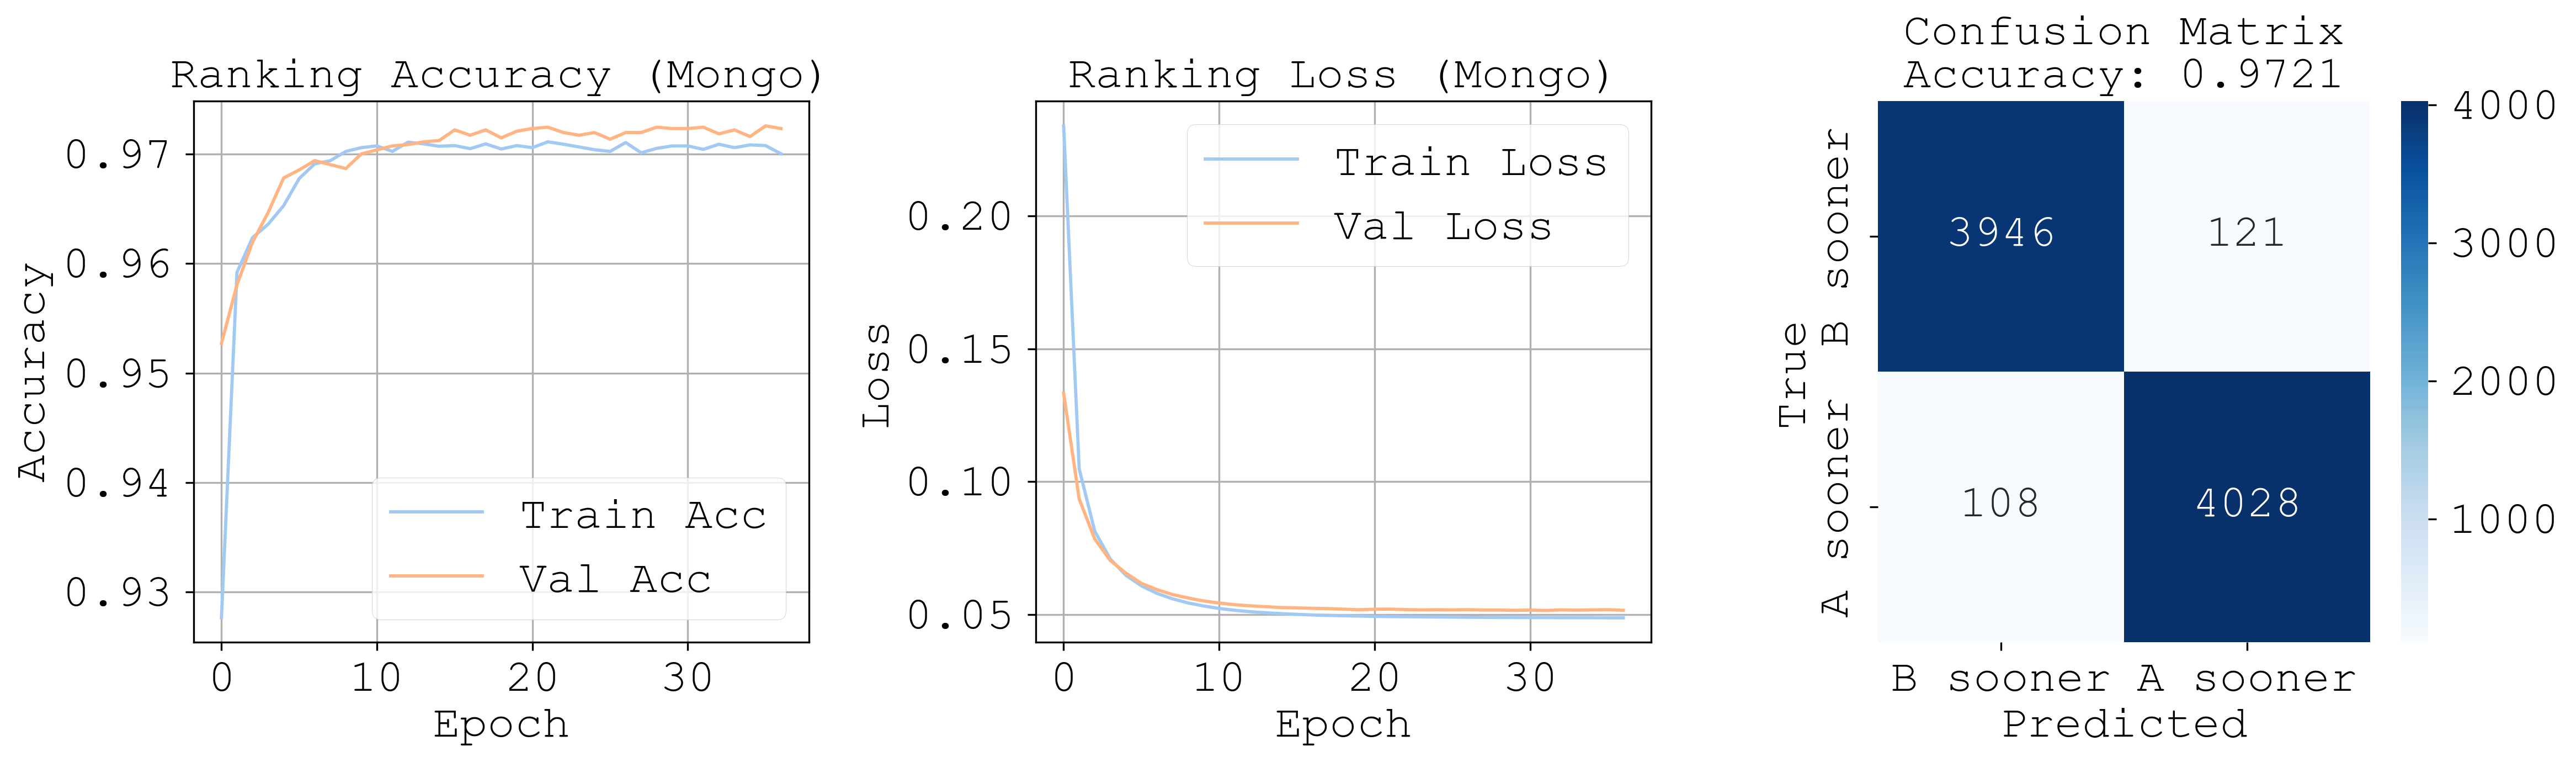

In [441]:
fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history["accuracy"], label="Train Acc")
ax1.plot(history.history["val_accuracy"], label="Val Acc")
ax1.set_title("Ranking Accuracy (Mongo)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history["loss"], label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Ranking Loss (Mongo)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_pairs.astype(int), Y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax3,
    xticklabels=["B sooner", "A sooner"],
    yticklabels=["B sooner", "A sooner"],
)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True")
ax3.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [438]:
w = model.get_layer("ranking_weight").get_weights()[0].ravel()

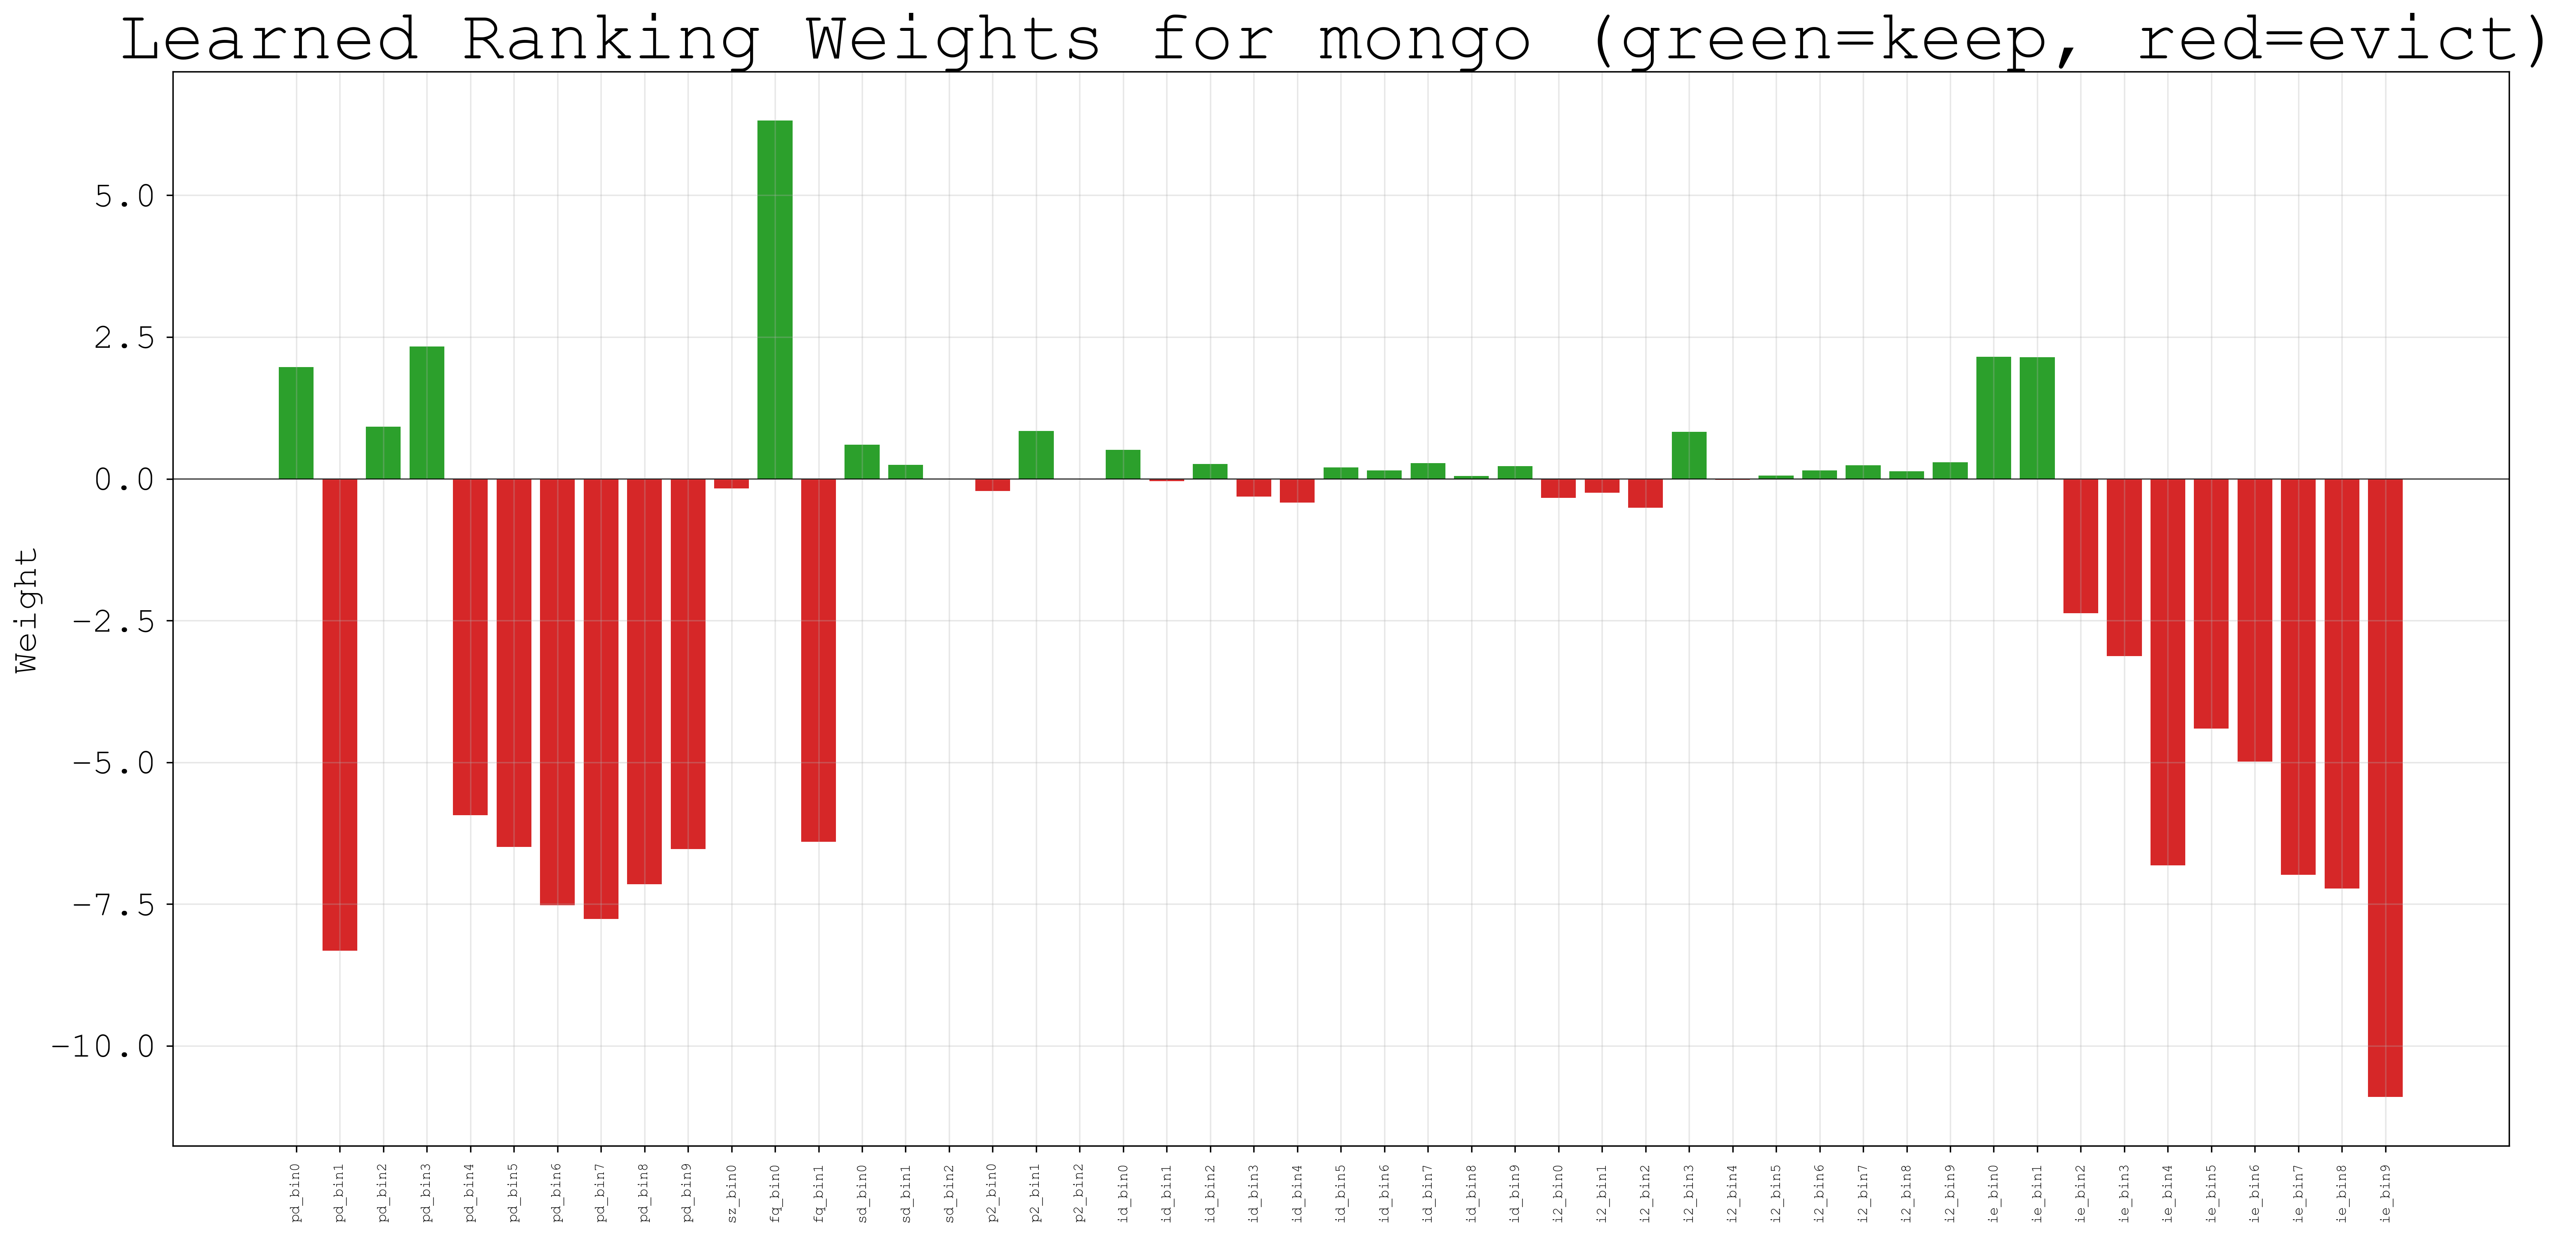

In [443]:
feature_names = []
for col, n_bins in zip(discretize_cols, n_bins_list):
    for b in range(n_bins):
        feature_names.append(f"{col}_bin{b}")

fig_w, ax_w = plt.subplots(figsize=(20, 10))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in w]
ax_w.bar(range(len(w)), w, color=colors)
ax_w.set_xticks(range(len(w)))
ax_w.set_xticklabels(feature_names, rotation=90, fontsize=8)
ax_w.set_ylabel("Weight")
ax_w.set_title("Learned Ranking Weights for mongo (green=keep, red=evict)")
ax_w.axhline(y=0, color="black", linewidth=0.5)
ax_w.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()